🏪 RETAIL DOMAIN EXPLORATION: DATA OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), objec

/tmp/ipykernel_1769/983665291.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=revenue_col, y=category_col, estimator=sum, errorbar=None, palette='viridis')


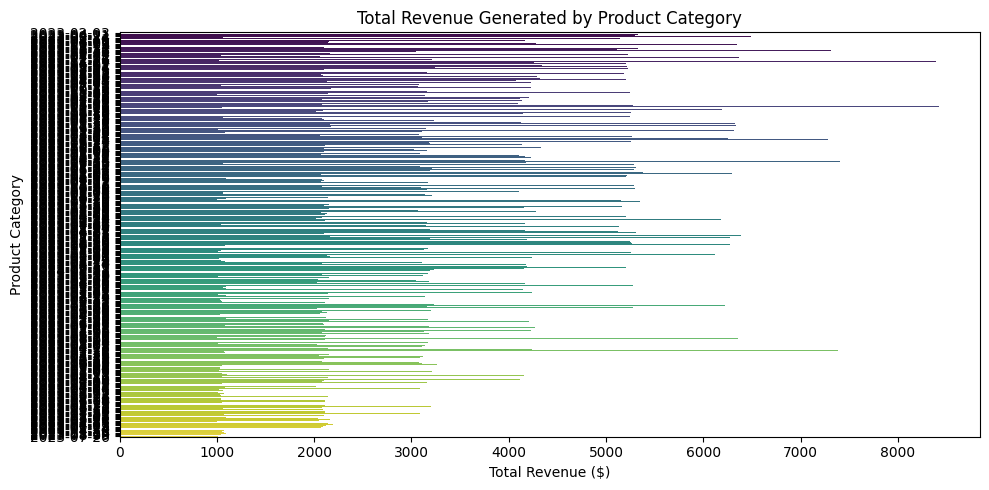

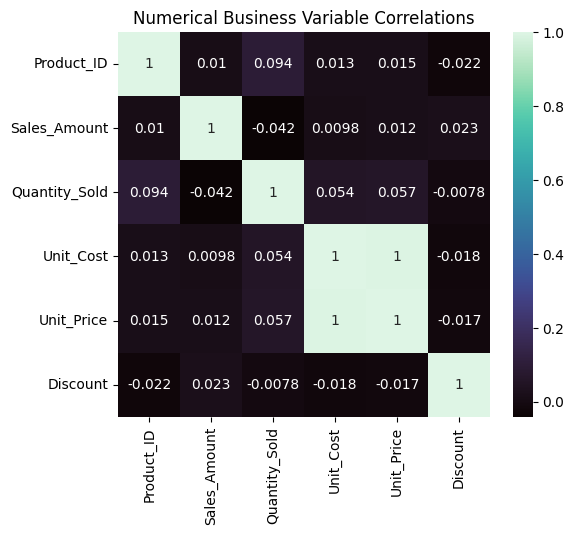

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the real-world domain dataset
# Make sure your uploaded file is named 'sales.csv' or change the string below
df = pd.read_csv('/content/sales_data.csv')

print("="*60)
print("🏪 RETAIL DOMAIN EXPLORATION: DATA OVERVIEW")
print("="*60)
print(df.info())
print(df.head())

# 2. Domain Feature Engineering (Calculating profit margins or totals if not present)
# If your dataset columns have slightly different names, adjust these variables!
if 'Cost' in df.columns and 'Revenue' in df.columns:
    df['Profit'] = df['Revenue'] - df['Cost']
    df['Margin_Percent'] = (df['Profit'] / df['Revenue']) * 100

print("\n" + "="*60)
print("📈 KEY BUSINESS METRICS SUMMARY")
print("="*60)
# General statistics to show business health
print(df.describe())

# 3. Domain Insight 1: Top Performing Product Categories
plt.figure(figsize=(10, 5))
# Assuming the column for category is 'Product line' or 'Category'
category_col = 'Product line' if 'Product line' in df.columns else df.select_dtypes(include=['object']).columns[0]
revenue_col = 'Total' if 'Total' in df.columns else df.select_dtypes(include=['number']).columns[0]

sns.barplot(data=df, x=revenue_col, y=category_col, estimator=sum, errorbar=None, palette='viridis')
plt.title('Total Revenue Generated by Product Category')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

# 4. Domain Insight 2: Sales Trends Over Time or Customer Payment Preferences
plt.figure(figsize=(6, 5))
payment_col = 'Payment' if 'Payment' in df.columns else None
if payment_col:
    df[payment_col].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
    plt.title('Customer Payment Method Distribution')
    plt.ylabel('')
    plt.show()
else:
    # Fallback to a correlation map of sales variables
    sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='mako')
    plt.title('Numerical Business Variable Correlations')
    plt.show()